# The aim of this notebook is to try and see how our analysis differ when we change the 'truth' data sets to every model. The first goal is to make RMSE plots.

In [110]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import corner 
from tqdm import tqdm
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
# plt.rcParams['text.usetex'] = False
# plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


#Another option for plotting
# pip install scienceplots
import scienceplots 
plt.style.use('science')


# #Some colors that Pablo likes:
colors = [
    "#1f77b4", # Vivid blue
    "#ff7f0e", # Bright orange
    "#2ca02c", # Rich green
    "#d62728", # Strong red
    "#9467bd", # Deep purple
    # "#8c564b", # Brownish-pink
    "#e377c2", # Pink
    "#7f7f7f", # Medium gray
    "#bcbd22", # Lime green
    "#17becf", # Cyan
    "#393b79", # Dark blue
    "#637939", # Olive green
    "#8c6d31", # Bronze
    # "#843c39", # Dark red
    # "#ad494a", # Reddish brown
    "#d6616b", # Soft red
    "#e7ba52", # Golden yellow
    "#7b4173", # Dark purple
    "#a55194", # Mauve
    "#ce6dbd", # Light purple
]

colors_sets = [
    "#ff7f0e",

    "#1f77b4",

    "#2ca02c",
    "#d62728",
    
    "#9467bd",
    "#8c564b",
    "#e377c2",
    "#7f7f7f",
    "#bcbd22",
    "#17becf",
    '#1f77b4',  # muted blue
    'r',  
] 

markers = [
    "o",  # Circle
    "^",  # Triangle up
    "s",  # Square
    "P",  # Plus (filled)
    "*",  # Star
    "X",  # X (filled)
    "D",  # Diamond
    "H",  # Hexagon
]


colors_models = colors


Selected_element=50
Selected_element_name="Sn"

color_train=colors_sets[9]
color_validation='orange'
color_test=colors_sets[3]

marker_trainig='s'
marker_validation='*'
marker_testing='o'



size_trainig=30
size_validation=80
size_testing=35

alpha_trainig=0.8
alpha_validation=0.9
alpha_testing=0.4

models = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
models_selected = [ 'ME2', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', \
        'UNEDF1']#Here I am copying all the models with Charge Raidus and Masses
key_list = models_selected[1:]

heterogeneous_data_type = ['BE', 'ChRad', 'CPn', 'CPp', 'PEn', 'PEp', 'QDB2n', 'QDB2p', 'QDB4n', 'QDB4p', 'MRadN', 'MRadP']
num_properties = 2

In [2]:
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}

filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [3]:
def separate_points_random(list1,random_chance):
    """
    Separates points in list1 into two groups randomly

    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]


    for i in range(len(list1)):
        point1=list1[i]
        val=np.random.rand()
        if val<=random_chance:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance(list1, list2, distance):
    """
    Separates points in list1 into two groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    test = []

    train_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            test.append(point1)
            test_list_coordinates.append(i)

    return np.array(train), np.array(test), np.array(train_list_coordinates), np.array(test_list_coordinates)

def separate_points_distance_allSets(list1, list2, distance1, distance2):
    """
    Separates points in list1 into three groups based on their proximity to any point in list2.

    :param list1: List of (x, y) tuples.
    :param list2: List of (x, y) tuples.
    :param distance: The threshold distance to determine proximity.
    :return: Two lists - close_points and distant_points.
    """
    train = []
    validation=[]
    test = []

    train_list_coordinates=[]
    validation_list_coordinates=[]
    test_list_coordinates=[]

    for i in range(len(list1)):
        point1=list1[i]
        close = False
        for point2 in list2:
            if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance1:
                close = True
                break
        if close:
            train.append(point1)
            train_list_coordinates.append(i)
        else:
            close2=False
            for point2 in list2:
                if np.linalg.norm(np.array(point1) - np.array(point2)) <= distance2:
                    close2 = True
                    break
            if close2==True:
                validation.append(point1)
                validation_list_coordinates.append(i)
            else:
                test.append(point1)
                test_list_coordinates.append(i)                

    return np.array(train),np.array(validation), np.array(test), np.array(train_list_coordinates),  np.array(validation_list_coordinates),np.array(test_list_coordinates)


In [4]:
def filtered_NZ_extraction(filtered_NZ): #This function will extract isotopes that we want in our analysis

    #We start applying constraints to the above NZ array
    filtered_NZ_new = [] # Create a new list
    for isotope in filtered_NZ:
        if ((isotope[0] >= 8) & (isotope[1] >= 8)) & ( (isotope[0]%2 == 0) & (isotope[1]%2 == 0) ):
            filtered_NZ_new.append(isotope) # Choose the isotope that satisfies the above condition
    filtered_NZ = np.array(filtered_NZ_new) # Turn this into an array
    return filtered_NZ

def unified_NZ(models_data_sets, models_selected, filtered_NZ):
    for model in models_selected: # Loop throught every model
        filtered_NZ_new = [] 
        for isotope in filtered_NZ:
            if ((models_data_sets[model]["N"] == isotope[0]) & (models_data_sets[model]["Z"] == isotope[1])).any():
                filtered_NZ_new.append(isotope) #Choose every isotope that does appears in the model we are considering
        filtered_NZ = np.array(filtered_NZ_new)# Update our list of filtered_NZ and loop through the remaining models.
    #A dataframe containing this NZ inputs
    filtered_NZ_df = {'N' : filtered_NZ.T[0], 'Z': filtered_NZ.T[1]}
    filtered_NZ_df = pd.DataFrame(filtered_NZ_df)

    return filtered_NZ, filtered_NZ_df

def selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, heterogeneous_data_type, num_properties, j):
    selected_models_data_sets_list = []
    for i in range(num_properties):
        selected_models_data_sets=pd.DataFrame(filtered_NZ_df)

        for model in models_selected:
            a = pd.merge(filtered_NZ_df, pd.DataFrame(models_data_sets[model]), how = 'inner', on  = ['N', 'Z'])
            selected_models_data_sets[model] = a[heterogeneous_data_type[i]]
        selected_models_data_sets.rename(columns={models_selected[j]: 'truth'}, inplace=True)
        cols = list(selected_models_data_sets.columns)
        cols[2], cols[j+2] = cols[j+2], cols[2]
        print(cols)
        selected_models_data_sets = selected_models_data_sets[cols]

        
        selected_models_data_sets_list.append(selected_models_data_sets)
    return selected_models_data_sets_list

def models_output_extraction(selected_models_data_sets, train_coordinates, validation_coordinates, test_coordinates):
    models_output = selected_models_data_sets #This gives the initial values for models output
    
    # We will add a column of mass number and rearrange our dataframe
    models_output["A"] = models_output["N"] + models_output["Z"] 
    cols = list(models_output.columns)
    cols[2], cols[-1] = cols[-1], cols[2]
    models_output = models_output[cols]

    #Next steps is to extract this dataframe at train,validation,test coordinates
    models_output_train = models_output.iloc[train_coordinates]
    models_output_validation = models_output.iloc[validation_coordinates]
    models_output_test = models_output.iloc[test_coordinates]

    return [models_output,models_output_train,models_output_validation,models_output_test]

def filtered_models_output(Selected_element, models_output_list): 
    Z_range=(Selected_element,Selected_element)
    N_range=(0,300)
    models_output, models_output_train, models_output_validation, models_output_test = models_output_list

    
    filtered_models_output = models_output[(models_output['Z'] >= Z_range[0]) & (models_output['Z'] <= Z_range[1]) & 
                         (models_output['N'] >= N_range[0]) & (models_output['N'] <= N_range[1])]  
    
    filtered_models_output_train = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'] >= N_range[0]) & (models_output_train['N'] <= N_range[1])]
    
    filtered_models_output_test = models_output_test[(models_output_test['Z'] >= Z_range[0]) & (models_output_test['Z'] <= Z_range[1]) & 
                         (models_output_test['N'] >= N_range[0]) & (models_output_test['N'] <= N_range[1])]
    
    filtered_models_output_validation = models_output_validation[(models_output_validation['Z'] >= Z_range[0]) & (models_output_validation['Z'] <= Z_range[1]) & 
                         (models_output_validation['N'] >= N_range[0]) & (models_output_validation['N'] <= N_range[1])]
    
    
    stable_selected_isotope=[]
    
    for i in range(len(stable_coordinates)):
        if stable_coordinates[i][1]==Selected_element:
            stable_selected_isotope.append(stable_coordinates[i])
    
    stable_selected_isotope=np.array(stable_selected_isotope)
    
    # df[df['Column1'].isin(values_array)]
    
    filtered_models_output_stable = models_output_train[(models_output_train['Z'] >= Z_range[0]) & (models_output_train['Z'] <= Z_range[1]) & 
                         (models_output_train['N'].isin(stable_selected_isotope.T[0]))]
    
    return [filtered_models_output,filtered_models_output_train, filtered_models_output_validation, filtered_models_output_test, filtered_models_output_stable]

def models_PC_output(Vt_hat, model_predictions, predictions_mean):
    models_PC = {}

    models_PC["PC_0"] = predictions_mean
    
    for i in range(components_kept):
        models_PC["PC_" + str(i+1)] = np.dot(Vt_hat[i], model_predictions.T)
    
    # models_PC["N"] = models_output["N"]
    # models_PC["Z"] = models_output["Z"]
    # models_PC["A"] = models_PC["N"] + models_PC["Z"]
    
    models_PC = pd.DataFrame(models_PC)

    return models_PC

def rndm_m_mass_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_mass = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_mass= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_mass.append(yvals_rand_mass +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_mass)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_mass),1.0 * samples[i][-2]**2 ) )))  
        
    lower_mass = np.percentile(rndm_m_mass, 2.5, axis = 0)
    median_mass = np.percentile(rndm_m_mass, 50, axis = 0)
    upper_mass = np.percentile(rndm_m_mass, 97.5, axis = 0)

    return [lower_mass, median_mass, upper_mass]

def rndm_m_radius_calculator(model_weights, filtered_model_predictions, samples):
    rndm_m_radius = []
    for i in range(len(model_weights)):
        if centering_data:
            yvals_rand_radius= filtered_model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m_radius.append(yvals_rand_radius +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand_radius)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand_radius),1.0 * samples[i][-1]**2 ) )))  
        
    lower_radius = np.percentile(rndm_m_radius, 2.5, axis = 0)
    median_radius = np.percentile(rndm_m_radius, 50, axis = 0)
    upper_radius = np.percentile(rndm_m_radius, 97.5, axis = 0)

    return [lower_radius, median_radius, upper_radius]

def rndm_m_mass_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-2]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m

def rndm_m_radius_calculator_coverage(samples, model_predictions, total_samples, Vt_hat):
    # %%time
    np.random.seed(142857)
    rng = np.random.default_rng()
    samples_rand = rng.choice(samples, min(total_samples, 100000), replace = False)

    model_weights = []
    for beta in samples_rand:
        model_weights.append(np.dot(beta[:-2], Vt_hat) + np.full(len(Vt_hat[0]) , 1/len(Vt_hat[0])))
    model_weights = np.array(model_weights)
    
    rndm_m = []
    for i in tqdm(range(len(model_weights))):
        if centering_data:
            yvals_rand= model_predictions.dot(model_weights[i].T)
        # else:
        #     yvals_rand= X_full_filtered.T.dot(theta_rand[i][0:-1])
    
        rndm_m.append(yvals_rand +
                       np.random.multivariate_normal(np.full(
                           len(yvals_rand)
                           ,0), np.diag(1.0 * np.full(len(yvals_rand),1.0 * samples_rand[i][-1]**2 ) ))) 
    rndm_m = np.array(rndm_m)
    return rndm_m
    

def coverage_calculation(rndm_m_full, models_output):
    percentiles = np.arange(0, 101, 5)


    data_total=len(rndm_m_full.T)
    data_true=models_output["truth"].tolist()
    M_evals=len(rndm_m_full)
    
    
    coverage = []
    
    for p in percentiles:
        count_covered = 0
        for i in range(data_total):
            # Sort model evaluations for the i-th data point
            sorted_evals = np.sort(rndm_m_full.T[i])
            
            # Find indices for lower and upper bounds of the credible interval
            lower_idx = int((0.5 - p / 200) * M_evals)
            upper_idx = int((0.5 + p / 200) * M_evals) - 1  # Adjusted to avoid out-of-bounds
            
            # Check if the true value y[i] is within this interval
            if sorted_evals[lower_idx] <= data_true[i] <= sorted_evals[upper_idx]:
                count_covered += 1
                
        # Calculate and store the coverage percentage
        coverage.append(count_covered / data_total * 100)
        
    return coverage
    

In [5]:
def PC_RMSE_calculator(components_kept, predictions_mean_list, models_output_list, model_predictions_list, U, S, Vt):  #A function that will basically run everything above (without the plots) with varying number of kept PCs

    predictions_mean = predictions_mean_list[0]
    predictions_mean_train = predictions_mean_list[1]
    predictions_mean_validation = predictions_mean_list[2]
    predictions_mean_test = predictions_mean_list[3]

    models_output = models_output_list[0]
    models_output_train = models_output_list[1]
    models_output_validation = models_output_list[2]
    models_output_test = models_output_list[3]

    model_predictions = model_predictions_list[0]
    model_predictions_train = model_predictions_list[1]
    model_predictions_validation = model_predictions_list[2]
    model_predictions_test = model_predictions_list[3]

    S_hat=np.array([S[i] for i in range(components_kept)])

    # U_hat=np.array([U.T[i]*S_hat[i] for i in range(components_kept)])
    U_hat=np.array([U.T[i]for i in range(components_kept)])

    # Vt_hat=np.array([Vt[i] for i in range(components_kept)])
    Vt_hat=np.array([Vt[i]/S_hat[i] for i in range(components_kept)])   


    if centering_data:
        num_components=components_kept+1
    else:
        num_components=components_kept



    #########################################
    #Creating principal components that are for training. These should be equivalent to \hat U, and if they are not there is something wrong
    models_PC_train = {}
    if centering_data:
        models_PC_train[str("PC_0")] = predictions_mean_train       
    for i in range(components_kept):
        models_PC_train[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_train.T)
    models_PC_train["N"] = models_output_train["N"]
    models_PC_train["Z"] = models_output_train["Z"]
    models_PC_train["A"] = models_PC_train["N"] + models_PC_train["Z"]
    # models_PC_training = pd.DataFrame(models_PC_train)
    models_PC_train = pd.DataFrame(models_PC_train)
    #########################################

    #########################################
    #Creating principal components that are for validation
    models_PC_validation = {}
    if centering_data:
        models_PC_validation[str("PC_0")] = predictions_mean_validation
    for i in range(components_kept):
        models_PC_validation[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_validation.T)
    models_PC_validation["N"] = models_output_validation["N"]
    models_PC_validation["Z"] = models_output_validation["Z"]
    models_PC_validation["A"] = models_PC_validation["N"] + models_PC_validation["Z"]
    models_PC_validation = pd.DataFrame(models_PC_validation)
    #########################################

    #########################################
    #Creating principal components that are for testing
    models_PC_testing = {}
    if centering_data:
        models_PC_testing[str("PC_0")] = predictions_mean_test
    for i in range(components_kept):
        # models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)*S_hat[i]
        models_PC_testing[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions_test.T)

    models_PC_testing["N"] = models_output_test["N"]
    models_PC_testing["Z"] = models_output_test["Z"]
    models_PC_testing["A"] = models_PC_testing["N"] + models_PC_testing["Z"]
    models_PC_testing = pd.DataFrame(models_PC_testing)
    #########################################

    #Creating principal components that are valid everywhere (testing + training + validation)
    models_PC = {}
    if centering_data:
        models_PC[str("PC_0")] = predictions_mean
    for i in range(components_kept):
        models_PC[str("PC_")+str(i+1)] = np.dot(Vt_hat[i],model_predictions.T)
    models_PC = pd.DataFrame(models_PC)
    models_PC["N"] = Full_set.T[0]
    models_PC["Z"] = Full_set.T[1]
    models_PC["A"] = models_PC["N"] + models_PC["Z"]
    #########################################

    key_list_PCs=list(models_PC_testing.keys())


    X=np.copy(U_hat)
    if centering_data:
        y=np.copy(models_output_train["truth"].tolist())-predictions_mean_train
    else:
        y=np.copy(models_output_train["truth"].tolist())
    #Making the list of principal components across the train part. These should be identical to the X on top made by \hat U
    X_train=[]
    for i in range(num_components):
        X_train.append(models_PC_train[key_list_PCs[i]].tolist())
    X_train=np.array(X_train)
    #Making the list of principal components across the validation part
    X_validation=[]
    for i in range(num_components):
        X_validation.append(models_PC_validation[key_list_PCs[i]].tolist())
    X_validation=np.array(X_validation)

    #Making the list of principal components across the testing part
    X_test=[]
    for i in range(num_components):
        X_test.append(models_PC_testing[key_list_PCs[i]].tolist())
    X_test=np.array(X_test)
    #Making the list of principal components across the entire chart (training+validation+testing)
    X_full=[]
    for i in range(num_components):
        X_full.append(models_PC[key_list_PCs[i]].tolist())
    X_full=np.array(X_full)

    X_train_centered = X_train[1:,:]

    # 1) Find the least square solution for the training part
    X_T_X_inv = np.linalg.inv(X_train_centered.dot(X_train_centered.T))
    beta = X_T_X_inv.dot(X_train_centered).dot(y)
    
    #1.5) Construct the super model across the entire range and the test range
    if centering_data:
        beta_full= np.insert(beta, 0, 1)  #Augmenting the beta list to add a "1" at the begining so it can use the PC0 (the mean)
    else:
        beta_full=np.copy(beta)

    # supermodel=X.T.dot(beta_full)
    supermodel=X_train.T.dot(beta_full)
    supermodel_train=np.copy(supermodel)
    supermodel_validation=X_validation.T.dot(beta_full)
    supermodel_test=X_test.T.dot(beta_full)
    supermodel_full=X_full.T.dot(beta_full)

    
    super_model_resituals_train=supermodel_train-models_output_train['truth'].tolist()
    super_model_residuals_validation= supermodel_validation-models_output_validation['truth'].tolist()
    super_model_residuals_test = supermodel_test-models_output_test['truth'].tolist()
    super_model_residuals_full = supermodel_full-models_output['truth'].tolist()

    sigma_train=np.sqrt(np.sum(super_model_resituals_train**2) / len(super_model_resituals_train) )
    sigma_validation=np.sqrt(np.sum(super_model_residuals_validation**2) / len(super_model_residuals_validation) )
    sigma_test=np.sqrt(np.sum(super_model_residuals_test**2) / len(super_model_residuals_test) )
    sigma_full=np.sqrt(np.sum(super_model_residuals_full**2) / len(super_model_residuals_full) )


    return [sigma_train,sigma_validation,sigma_test,sigma_full]

In [77]:
def RMSE_one_line_calculator_mass(j):
    # Extracting 2 data frames that contains predictions of different properties of nuclei
    selected_models_data_sets_mass, selected_models_data_sets_radius = selected_models_data_sets_extraction(filtered_NZ_df, models_data_sets, models_selected, \
                                                                                                        heterogeneous_data_type, num_properties, j)
    
    key_list = list(selected_models_data_sets_mass.keys())[3:]
    
    # When we have 2 different data frames, extract the models_output_list from these data sets
    #Extract models output of different categories (mass and radius) and classify them into 4 regions: all,train, validation, test
    models_output_mass_list = models_output_extraction(selected_models_data_sets_mass, train_coordinates, validation_coordinates, test_coordinates)
    models_output_radius_list = models_output_extraction(selected_models_data_sets_radius, train_coordinates, validation_coordinates, test_coordinates)
    
    model_predictions_mass=models_output_mass_list[0][key_list].values
    model_predictions_mass_train=models_output_mass_list[1][key_list].values
    model_predictions_mass_validation=models_output_mass_list[2][key_list].values
    model_predictions_mass_test=models_output_mass_list[3][key_list].values

    predictions_mean_mass= np.mean(model_predictions_mass, axis=1)
    predictions_mean_mass_train= np.mean(model_predictions_mass_train, axis=1)
    predictions_mean_mass_validation= np.mean(model_predictions_mass_validation, axis=1)
    predictions_mean_mass_test= np.mean(model_predictions_mass_test, axis=1)

    model_predictions_radius=models_output_radius_list[0][key_list].values
    model_predictions_radius_train=models_output_radius_list[1][key_list].values
    model_predictions_radius_validation=models_output_radius_list[2][key_list].values
    model_predictions_radius_test=models_output_radius_list[3][key_list].values

    predictions_mean_radius= np.mean(model_predictions_radius, axis=1)
    predictions_mean_radius_train= np.mean(model_predictions_radius_train, axis=1)
    predictions_mean_radius_validation= np.mean(model_predictions_radius_validation, axis=1)
    predictions_mean_radius_test= np.mean(model_predictions_radius_test, axis=1)

    model_predictions_combined = np.vstack((model_predictions_mass, model_predictions_radius))
    model_predictions_combined_train = np.vstack((model_predictions_mass_train, model_predictions_radius_train))
    model_predictions_combined_validation = np.vstack((model_predictions_mass_validation, model_predictions_radius_validation))
    model_predictions_combined_test = np.vstack((model_predictions_mass_test, model_predictions_radius_test))

    predictions_mean_combined= np.mean(model_predictions_combined, axis=1)
    predictions_mean_combined_train= np.mean(model_predictions_combined_train, axis=1)
    predictions_mean_combined_validation= np.mean(model_predictions_combined_validation, axis=1)
    predictions_mean_combined_test= np.mean(model_predictions_combined_test, axis=1)

    predictions_mean_mass_list = [predictions_mean_mass, predictions_mean_mass_train, predictions_mean_mass_validation, predictions_mean_mass_test]
    models_output_mass_list = models_output_mass_list
    model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

    predictions_mean_radius_list = [predictions_mean_mass, predictions_mean_mass_train, predictions_mean_mass_validation, predictions_mean_mass_test]
    models_output_mass_list = models_output_mass_list
    model_predictions_mass_list = [model_predictions_mass, model_predictions_mass_train, model_predictions_mass_validation, model_predictions_mass_test]

    if centering_data:
        model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, None]
        model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train.reshape(600,1)
        model_predictions_combined_train_processed = model_predictions_combined_train - predictions_mean_combined_train[:, np.newaxis]

    # This is where we perfrom the PCA
    U, S, Vt = np.linalg.svd(model_predictions_combined_train_processed)

    # This is where we start to use the RMSE calculator 
    if centering_data:
        s_mass_validation=[np.linalg.norm(np.array(models_output_mass_list[2]["truth"].tolist())-predictions_mean_mass_validation)/np.sqrt(len(predictions_mean_mass_validation))]
        s_mass_test=[np.linalg.norm(np.array(models_output_mass_list[3]["truth"].tolist())-predictions_mean_mass_test)/np.sqrt(len(predictions_mean_mass_test))]
        s_mass_train=[np.linalg.norm(np.array(models_output_mass_list[1]["truth"].tolist())-predictions_mean_mass_train)/np.sqrt(len(predictions_mean_mass_train))]
        s_mass_all=[np.linalg.norm(np.array(models_output_mass_list[0]["truth"].tolist())-predictions_mean_mass)/np.sqrt(len(predictions_mean_mass))]

    
    if centering_data:
        for i in range(1,len(S)):
            res=PC_RMSE_calculator(i, predictions_mean_mass_list, models_output_mass_list, model_predictions_mass_list, U , S, Vt)
            s_mass_train.append(res[0])
            s_mass_validation.append(res[1])
            s_mass_test.append(res[2])
            
            s_mass_all.append(res[3])

    return [s_mass_all, s_mass_train, s_mass_validation, s_mass_test]

    

In [78]:
models_data_sets = {}
for model in models:
    Data_Values = pd.read_hdf("./data./selected_data.h5", key = model)
    models_data_sets[model] = {"N" : Data_Values["N"], "Z" : Data_Values["Z"], "BE" : Data_Values["BE"], 'ChRad': Data_Values['ChRad']}

filtered_NZ = np.array([models_data_sets[models_selected[0]]['N'].tolist(), models_data_sets[models_selected[0]]['Z'].tolist() ]).T
filtered_NZ

array([[  2,   2],
       [  4,   2],
       [  6,   2],
       ...,
       [156, 108],
       [158, 108],
       [160, 110]])

In [79]:
stable_coordinates_full=np.loadtxt("Stable-Isotopes.txt")
stable_coordinates = filtered_NZ_extraction(stable_coordinates_full)

In [80]:
filtered_NZ= filtered_NZ_extraction(filtered_NZ) #Extract even even nuclei with N, Z >= 8
filtered_NZ, filtered_NZ_df = unified_NZ(models_data_sets, models_selected, filtered_NZ) #Choose nuclei that appears in every models of interest

In [81]:
Full_set = np.copy(filtered_NZ)

In [82]:
#Traditional way with stable coordinates to seperate our data points

distance1=2
distance2=3

training_set, validation_set, test_set,train_coordinates, validation_coordinates,test_coordinates=separate_points_distance_allSets(filtered_NZ, stable_coordinates, distance1, distance2)

In [83]:
centering_data = True

In [84]:
# Let's first try to define a dictionary that contains all the the list of all sigma list

s_mass_dict = {}
for i in range(len(models_selected)):
    s_mass_dict[f's_mass_{i}'] = RMSE_one_line_calculator_mass(i)
    

['N', 'Z', 'truth', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'ME2', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'ME2', 'PC1', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'ME2', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'ME2', 'NL3S', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'ME2', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'ME2', 'SKMS', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'NL3S', 'ME2', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'NL3S', 'ME2', 'SKP', 'SLY4', 'SV', 'UNEDF0', 'UNEDF1']
['N', 'Z', 'truth', 'MEdelta', 'PC1', 'NL3S', 'SKMS', 'ME2', '

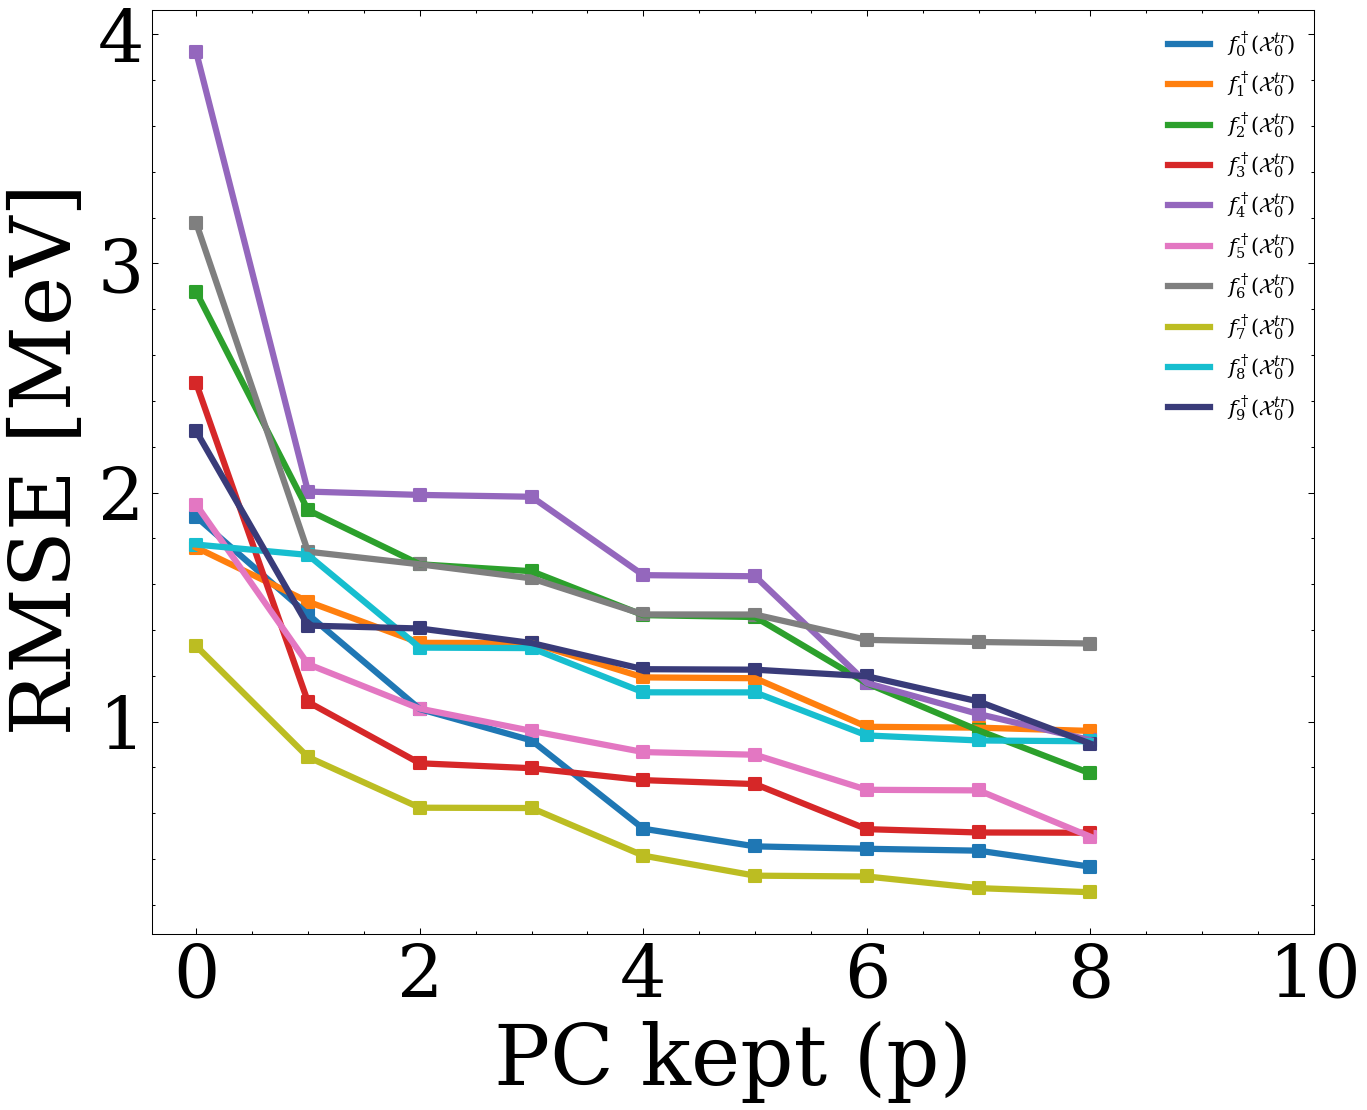

In [89]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


size_points=150

for i in range(len(models_selected)):
    ax.scatter(np.arange(0,len(s_mass_dict[f's_mass_{i}'][1])), s_mass_dict[f's_mass_{i}'][1],color=colors[i],s=30,marker=marker_trainig)
    ax.plot(np.arange(0,len(s_mass_dict[f's_mass_{i}'][1])), s_mass_dict[f's_mass_{i}'][1],color=colors[i],linewidth=3,label= f'$f^\dagger_{i}(\mathcal{{X}}_0^{{tr}})$')

# ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_test)), s_test,color=color_testing,s=size_points,marker=marker_testing)
# ax.plot(np.arange(0,len(s_test)), s_test,color=color_testing,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
ax.set_xticks([0,2,4,6,8,10])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')

plt.legend(fontsize=10)
plt.show()

In [90]:
s_mass_dict[f's_mass_0'][1] #This is to check if the train sigma we have is the same for the other notebook where we use ME2 as the truth value

[1.8941602277145955,
 1.4679875084347738,
 1.0547920589909232,
 0.9177709666471202,
 0.5322504505222673,
 0.455234984212939,
 0.444767280969408,
 0.43644803061170884,
 0.3664393788516513]

In [98]:
s_mass_dict[f's_mass_0'][2]

[2.5516161411136182,
 1.8043048618289734,
 1.139858297531309,
 0.9781101425277916,
 0.6921608512408751,
 0.721628674087164,
 0.7461971091112626,
 0.7636947951382375,
 0.5883013921529503]

In [99]:
s_mass_dict[f's_mass_0'][3]

[2.949107601379027,
 1.5593098438326465,
 1.2771693582640582,
 1.142224176933247,
 0.9280429795622425,
 0.9343672776394772,
 0.9535527334955991,
 1.0055986532207761,
 0.7602183783049341]

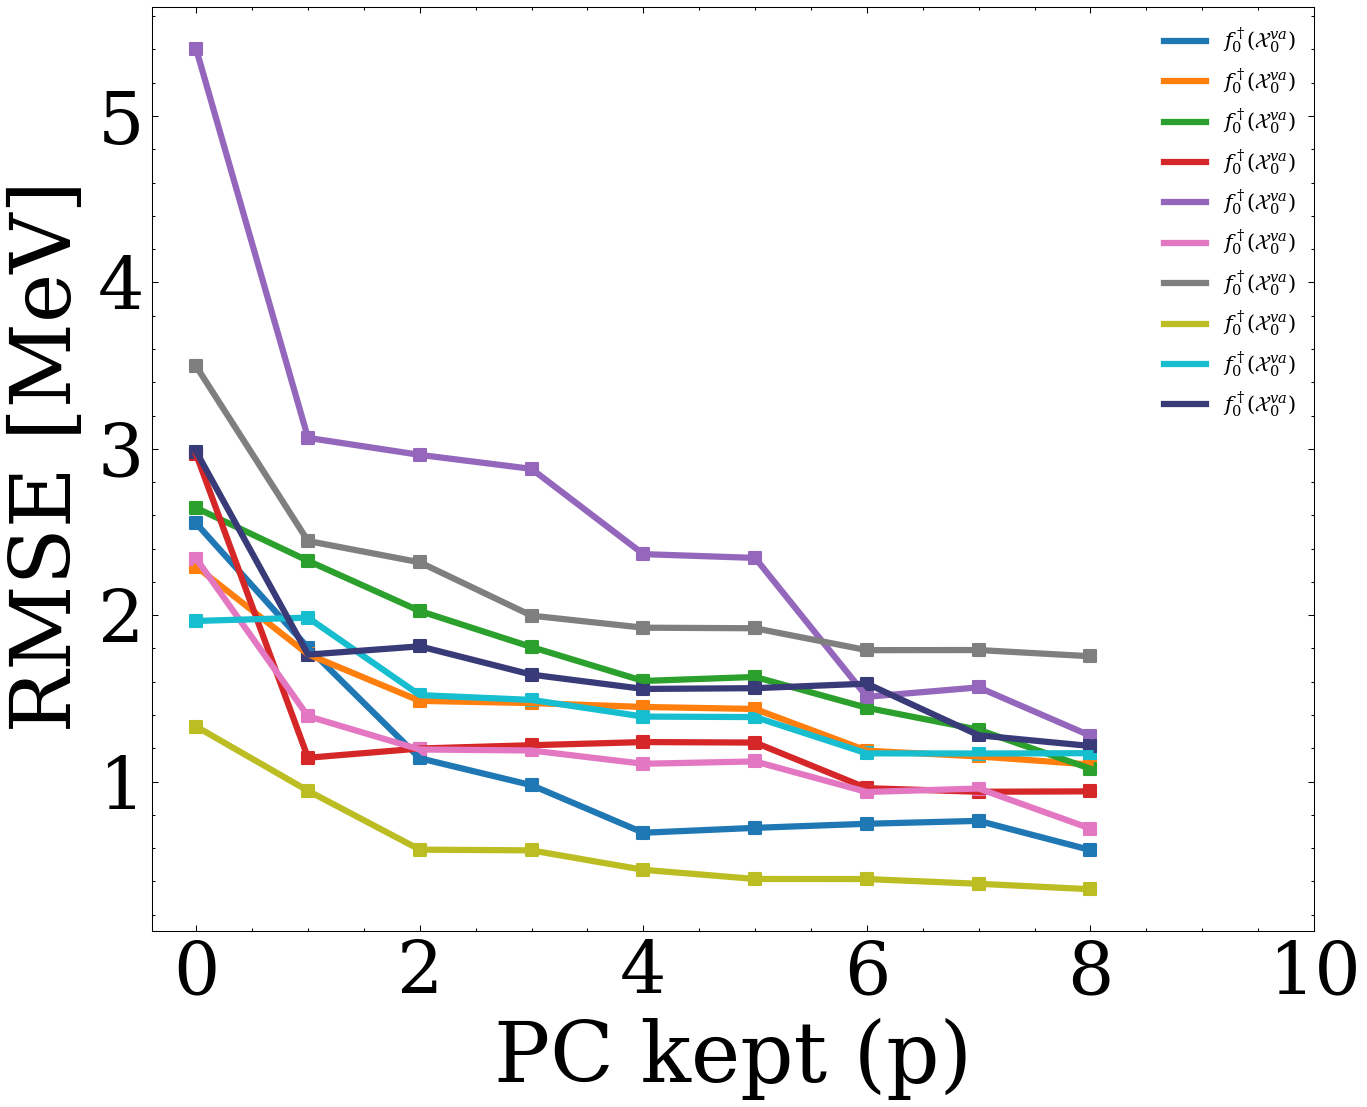

In [97]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


size_points=150

for i in range(len(models_selected)):
    ax.scatter(np.arange(0,len(s_mass_dict[f's_mass_{i}'][2])), s_mass_dict[f's_mass_{i}'][2],color=colors[i],s=30,marker=marker_trainig)
    ax.plot(np.arange(0,len(s_mass_dict[f's_mass_{i}'][2])), s_mass_dict[f's_mass_{i}'][2],color=colors[i],linewidth=3,label= f'$f^\dagger_{0}(\mathcal{{X}}_0^{{va}})$')

# ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_test)), s_test,color=color_testing,s=size_points,marker=marker_testing)
# ax.plot(np.arange(0,len(s_test)), s_test,color=color_testing,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
ax.set_xticks([0,2,4,6,8,10])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')

plt.legend(fontsize=10)
plt.show()

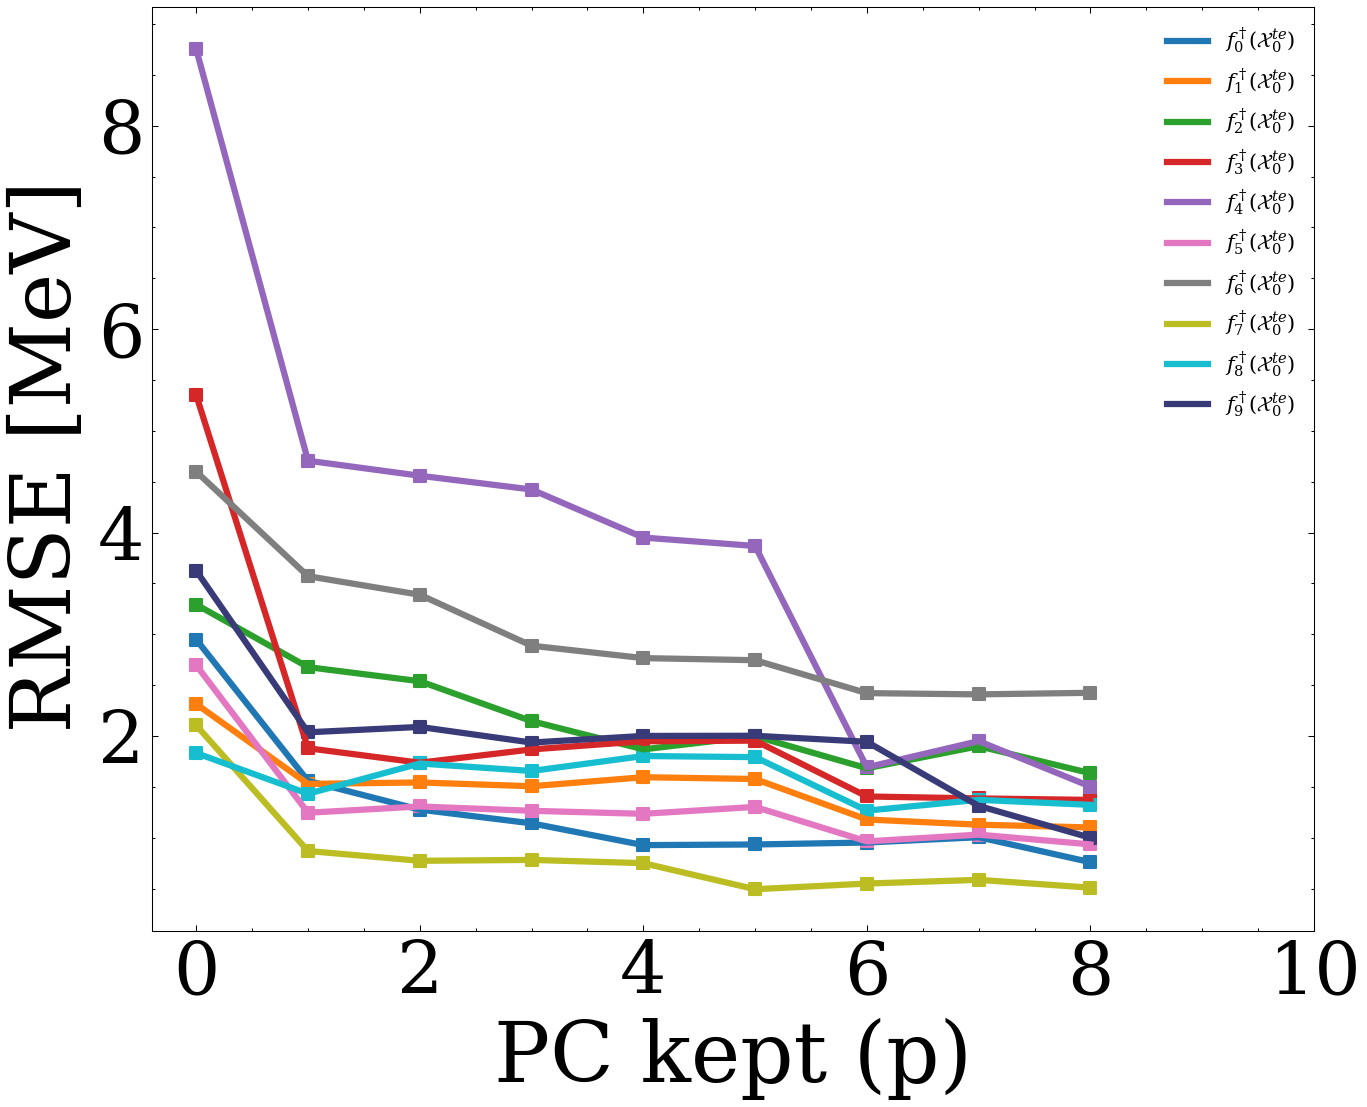

In [93]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')
plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


size_points=150

for i in range(len(models_selected)):
    ax.scatter(np.arange(0,len(s_mass_dict[f's_mass_{i}'][3])), s_mass_dict[f's_mass_{i}'][3],color=colors[i],s=30,marker=marker_trainig)
    ax.plot(np.arange(0,len(s_mass_dict[f's_mass_{i}'][3])), s_mass_dict[f's_mass_{i}'][3],color=colors[i],linewidth=3,label= f'$f^\dagger_{i}(\mathcal{{X}}_0^{{te}})$')

# ax.scatter(np.arange(0,len(s_validation)), s_validation,color=color_validation,s=size_points*1.3,marker=marker_validation)
# ax.plot(np.arange(0,len(s_validation)), s_validation,color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


# ax.scatter(np.arange(0,len(s_test)), s_test,color=color_testing,s=size_points,marker=marker_testing)
# ax.plot(np.arange(0,len(s_test)), s_test,color=color_testing,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
ax.set_xticks([0,2,4,6,8,10])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')

plt.legend(fontsize=10)
plt.show()

In [109]:
s_mass_sum = np.zeros((4,9))
for i in range(len(models_selected)):
    s_mass_sum += np.array(s_mass_dict[f's_mass_{i}'])

s_mass_mean = s_mass_sum/(len(models_selected) + 1)
s_mass_mean

array([[2.78731102, 1.68895162, 1.55866465, 1.47405307, 1.36060571,
        1.34464531, 1.05538229, 1.03540392, 0.92842512],
       [2.12937418, 1.36267997, 1.18090756, 1.14239603, 0.97090392,
        0.95152056, 0.80072364, 0.7496009 , 0.67675094],
       [2.54267486, 1.69410441, 1.47680174, 1.38721136, 1.25429929,
        1.25181679, 1.06751456, 1.02826061, 0.926398  ],
       [3.41120277, 1.95575289, 1.90460099, 1.78354256, 1.71381485,
        1.69772275, 1.27860811, 1.28065052, 1.14249831]])

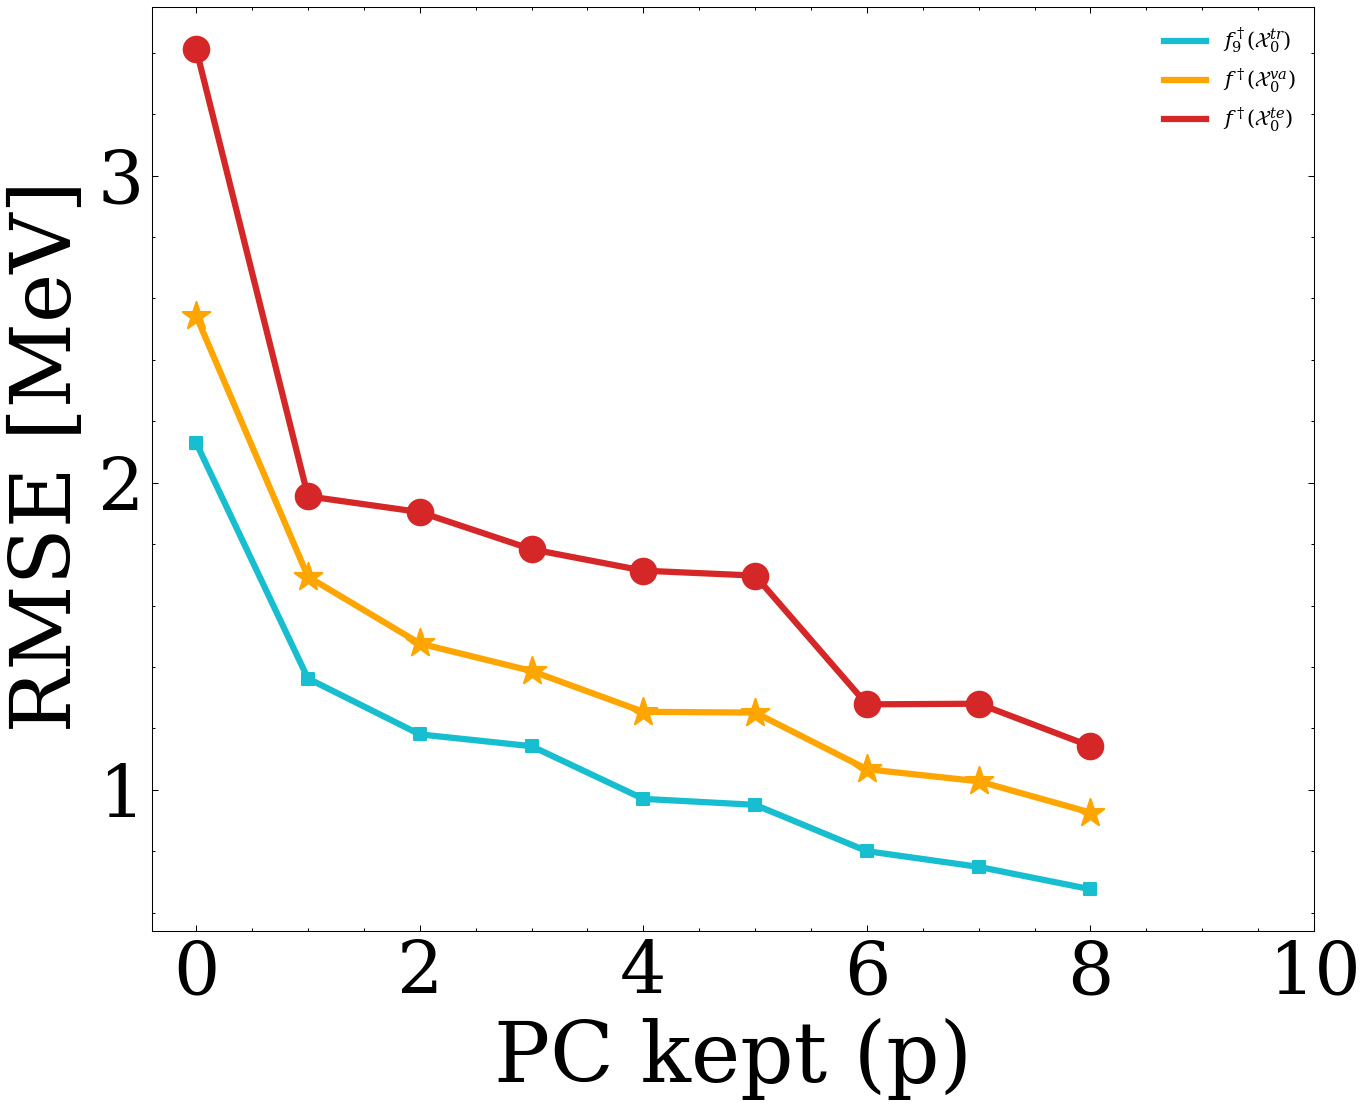

In [115]:
plt.rc("xtick", labelsize=35)
plt.rc("ytick", labelsize=35)

fig, ax = plt.subplots(figsize=(10,8),dpi=150)
fig.patch.set_facecolor('white')

plt.rcParams['text.usetex'] = False
plt.rcParams['text.latex.preamble'] = r'\usepackage{amsmath}'


size_points=150


ax.scatter(np.arange(0,len(s_mass_mean[1])), s_mass_mean[1],color=color_train,s=30,marker=marker_trainig)
ax.plot(np.arange(0,len(s_mass_mean[1])), s_mass_mean[1],color=color_train,linewidth=3,label= f'$f^\dagger_{i}(\mathcal{{X}}_0^{{tr}})$')

ax.scatter(np.arange(0,len(s_mass_mean[2])), s_mass_mean[2],color=color_validation,s=size_points*1.3,marker=marker_validation)
ax.plot(np.arange(0,len(s_mass_mean[2])), s_mass_mean[2],color=color_validation,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{va})$")


ax.scatter(np.arange(0,len(s_mass_mean[3])), s_mass_mean[3],color=color_testing,s=size_points,marker=marker_testing)
ax.plot(np.arange(0,len(s_mass_mean[3])), s_mass_mean[3],color=color_testing,linewidth=3,label="$f^\dagger(\mathcal{X}_0^{te})$")

# ax.axhline(y=sigma_naive_train,color=color_trainig,label="BMC$(\mathcal{X}_0^{tr})$",linestyle='dashed',linewidth=3)

# ax.axhline(y=sigma_naive_test,color=color_testing,label="BMC$(\mathcal{X}_0^{te})$",linestyle='dashed',linewidth=3)








# ax.set_yticks([0.2,0.5,1,2])


# ax.set_yscale('log')
ax.set_xlabel(r'PC kept (p)',fontsize=40)
ax.set_ylabel(r' RMSE [MeV]',fontsize=40);
ax.set_xticks([0,2,4,6,8,10])

# plt.ylim(2.5*10**(-1),2.3)

# plt.legend(fontsize=20,loc=(0.1,0.6))
# plt.savefig('Plots/Heterogenous RMSE change as number of PCs')

plt.legend(fontsize=10)
plt.show()